In [1]:
from MoREST import morest
Al2F2_10 = morest()
Al2F2_10.phase_space_sampling()

C:\Users\which\AppData\Roaming\Python\Python38\site-packages\sklearn\base.py:324: UserWarning: Trying to unpickle estimator GaussianProcessRegressor from version 0.24.2 when using version 1.0.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from ase.calculators.gaussian import Gaussian

calculator = Gaussian(label='gjf', cpu='0-39', mem='12GB', chk='gjf.chk', charge=0, \
                      method='b3lyp', basis='def2svp', geom='NoCrowd', scf='yqc', nosymm='nosymm')



In [10]:
from ase.io import read

In [3]:
test = read('MoREST.str', format='xyz')

In [4]:
test.get_masses()

array([26.9815385 , 18.99840316, 26.9815385 , 18.99840316])

In [5]:
from ase import units

In [6]:
units.kg

6.0221408585491615e+26

In [7]:
units.mol

6.022140857e+23

In [8]:
units.kg/units.mol

1000.0000002572443

In [9]:
units.Ang

1.0

In [10]:
units.fs

0.09822694788464063

In [11]:
(1/units.fs)**2

103.64269572045424

In [12]:
(1/units.fs)**2 * units.kg

6.241509125883258e+28

In [13]:
import numpy as np

In [19]:
units.s /(units.m * np.sqrt(units.kg/units.J) )

1.0

In [23]:
(units.s/units.m)**2 * units.J / units.kg

1.0

In [24]:
(1/units.fs/1)**2 * 1

103.64269572045424

In [27]:
test.get_masses() / units.kg

array([4.48038980e-26, 3.15475901e-26, 4.48038980e-26, 3.15475901e-26])

In [28]:
1.1531805312624011e-15/694461548335.367

1.6605390666000003e-27

In [29]:
1/units.Bohr

1.8897261258369282

In [1]:
from ase.io import read
import matplotlib.pyplot as plt
import many_body_potential
import numpy as np
from ase import units

In [2]:
test = read('../../../fhicloud-wang/Al2F2/MoREST_traj.xyz', index=':', format='extxyz')

In [3]:
ml = many_body_potential.ml_potential('../../../fhicloud-wang/Al2F2/pes_4_body/GPR_Al2F2_Etotal.joblib')

C:\Users\which\AppData\Roaming\Python\Python38\site-packages\sklearn\base.py:561: FutureWarning: Arrays of bytes/strings is being converted to decimal numbers if dtype='numeric'. This behavior is deprecated in 0.24 and will be removed in 1.1 (renaming of 0.26). Please convert your data to numeric values explicitly instead.
  X = check_array(X, **check_params)


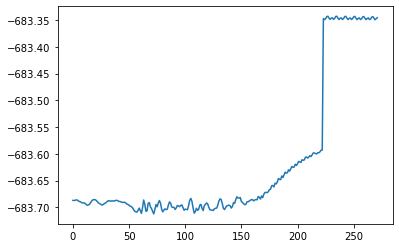

In [4]:
plt.plot(range(len(test)),ml.get_ml_potential(test)/units.Hartree,'-')
plt.show()

In [19]:
testz = test[10]
testz.get_velocities()

array([[-0.00572648,  0.01571154,  0.07819925],
       [ 0.01391849, -0.01504173, -0.08661486],
       [ 0.02161966,  0.01067406, -0.01888493],
       [-0.02981167, -0.01134387,  0.02730055]])

In [20]:
total = np.sum(testz.get_velocities(), axis=0)/len(testz.get_velocities())
total

array([6.31303482e-11, 7.01252203e-11, 9.27718640e-11])

In [21]:
tranzero = testz.get_velocities() - total
tranzero

array([[-0.00572648,  0.01571154,  0.07819925],
       [ 0.01391849, -0.01504173, -0.08661486],
       [ 0.02161966,  0.01067406, -0.01888493],
       [-0.02981168, -0.01134388,  0.02730055]])

In [22]:
np.sum(tranzero, axis=0)

array([0.00000000e+00, 0.00000000e+00, 1.04083409e-17])

In [24]:
mass = testz.get_masses()
mass

array([26.9815385 , 18.99840316, 26.9815385 , 18.99840316])

In [25]:
pos = testz.get_positions()
pos

array([[-0.31526101, -4.23528414,  0.46107114],
       [ 0.65665495, -5.4842403 ,  0.93652299],
       [ 0.24260513,  5.05317735,  1.54869446],
       [-0.57676501,  4.68051151,  0.16898637]])

In [31]:
center_of_mass = np.sum([mass[i]*pos[i] for i in range(len(mass))], axis=0)/np.sum(mass)
center_of_mass

array([-0.00481282,  0.07392847,  0.81806846])

In [32]:
r_vector = pos - center_of_mass
r_vector

array([[-0.31044819, -4.30921261, -0.35699732],
       [ 0.66146777, -5.55816877,  0.11845453],
       [ 0.24741795,  4.97924888,  0.730626  ],
       [-0.57195219,  4.60658304, -0.64908209]])

In [33]:
v_vector = testz.get_velocities()
v_vector

array([[-0.00572648,  0.01571154,  0.07819925],
       [ 0.01391849, -0.01504173, -0.08661486],
       [ 0.02161966,  0.01067406, -0.01888493],
       [-0.02981167, -0.01134387,  0.02730055]])

In [36]:
np.cross(r_vector[1], v_vector[1])

array([0.48320179, 0.05894165, 0.06741171])

In [44]:
r_cross_v = np.cross(r_vector, v_vector)
r_cross_v

array([[-0.3313682 ,  0.02632115, -0.02955425],
       [ 0.48320179,  0.05894165,  0.06741171],
       [-0.10183152,  0.02046836, -0.10500874],
       [ 0.11839914,  0.03496483,  0.14381811]])

In [45]:
r_2 = np.linalg.norm(r_vector, axis=1)**2
r_2

array([18.79313849, 31.34481117, 25.38794939, 21.96904417])

In [47]:
omega = np.array([r_cross_v[i]/r_2[i] for i in range(4)])
omega

array([[-0.0176324 ,  0.00140057, -0.00157261],
       [ 0.01541569,  0.00188043,  0.00215065],
       [-0.00401102,  0.00080622, -0.00413616],
       [ 0.00538936,  0.00159155,  0.0065464 ]])

In [56]:
rotat_vector = np.sum(omega, axis=0)/len(mass)
print(rotat_vector)
rotatzero = omega - np.sum(omega, axis=0)/len(mass)
rotatzero

[-0.00020959  0.00141969  0.00074707]


array([[-1.74228103e-02, -1.91208664e-05, -2.31967727e-03],
       [ 1.56252798e-02,  4.60734205e-04,  1.40358114e-03],
       [-3.80142480e-03, -6.13469958e-04, -4.88323329e-03],
       [ 5.59895537e-03,  1.71856619e-04,  5.79932943e-03]])

In [52]:
np.sum(rotatzero, axis=0)

array([-8.67361738e-19,  1.08420217e-19, -8.67361738e-19])

In [57]:
np.cross(rotat_vector, r_vector[2])

array([-0.00268258,  0.00033797, -0.00139487])

In [55]:
v_tang = np.cross(rotat_vector, r_vector)
v_tang

array([[ 0.00271245, -0.00030675,  0.00134392],
       [ 0.0043205 ,  0.00051899,  0.00022587],
       [-0.00268258,  0.00033797, -0.00139487],
       [-0.00436293, -0.00056333, -0.00015351]])

In [58]:
v_vector - v_tang

array([[-0.00843893,  0.01601829,  0.07685532],
       [ 0.00959799, -0.01556072, -0.08684074],
       [ 0.02430224,  0.01033609, -0.01749006],
       [-0.02544874, -0.01078054,  0.02745406]])

In [6]:
log = np.loadtxt('MoREST_MD.log').T

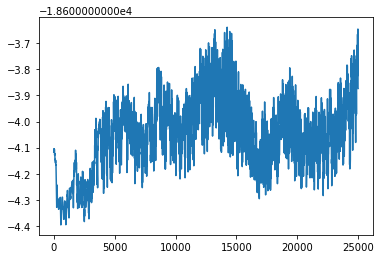

In [8]:
plt.plot(log[0], log[-1], '-')

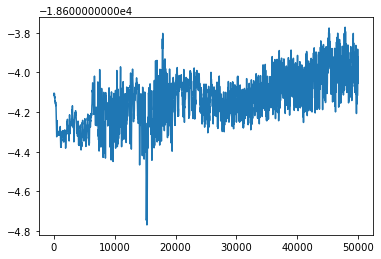

In [3]:
log = np.loadtxt('MoREST_MD.log').T
plt.plot(log[0], log[-1], '-')

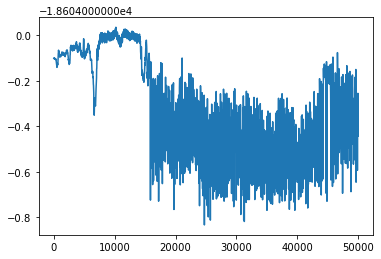

In [7]:
log = np.loadtxt('MoREST_MD.log').T
plt.plot(log[0], log[-1], '-')

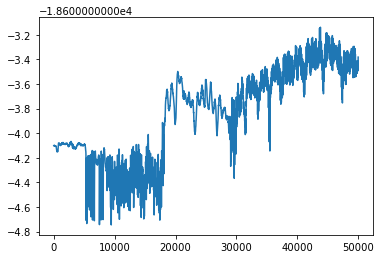

In [10]:
log = np.loadtxt('MoREST_MD.log').T
plt.plot(log[0], log[-1], '-')

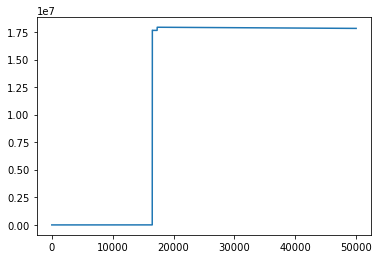

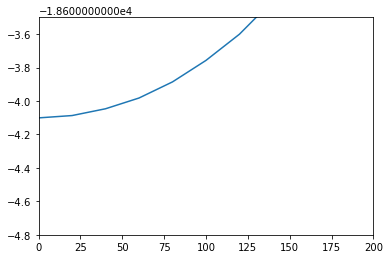

In [38]:
log = np.loadtxt('MoREST_MD.log').T
plt.plot(log[0], log[-1], '-')
plt.show()
plt.plot(log[0], log[-1], '-')
plt.xlim(0,200)
plt.ylim(-18604.8, -18603.5)
plt.show()

In [4]:
from ase.io import read
import numpy as np

In [2]:
test = read('./MoREST_traj.xyz', format='extxyz')

In [5]:
test.get_masses()[:, np.newaxis]

array([[26.9815385 ],
       [18.99840316],
       [26.9815385 ],
       [18.99840316]])

In [6]:
test.get_momenta()

array([[ 1.35290077, -1.81466721,  2.48594267],
       [-1.14166512,  1.29185889, -2.25538736],
       [-0.91442853,  1.32991289,  0.47073026],
       [ 0.70319288, -0.80710457, -0.70128557]])

In [7]:
test.get_momenta()*test.get_masses()[:,np.newaxis]

array([[ 36.50334421, -48.96251319,  67.07455786],
       [-21.68981423,  24.54325602, -42.84875835],
       [-24.67268859,  35.88309584,  12.70102663],
       [ 13.35954184, -15.33369802, -13.32330599]])

In [12]:
np.sum(test.get_masses()[:,np.newaxis] * test.get_positions())

76.51465499227109

In [11]:
test.get_positions()*test.get_masses()[:,np.newaxis]

array([[   0.82395737, -130.75115304,   22.42131097],
       [   1.0480927 , -118.61053273,   -3.86257523],
       [  -1.6318966 ,  138.83128091,   50.39738439],
       [  -0.43166785,  110.42889872,    7.85155538]])

In [13]:
np.sum(0.5 * test.get_masses()[:,np.newaxis] * np.linalg.norm(test.get_velocities())**2)

2.1276857961932327

In [14]:
0.5 * test.get_masses()[:,np.newaxis] * np.linalg.norm(test.get_velocities())**2

array([[0.62427478],
       [0.43956811],
       [0.62427478],
       [0.43956811]])